Лабораторна робота №1 — Класифікація цін на фрукти (варіант №3)

**Середовище:** Vertex AI Colab Enterprise (GCP)  
**Датасет:** Kaggle — *Fruit and Vegetable Prices*  
**Мета:** побудувати мінімальний, прозорий ML-пайплайн класифікації (low/mid/high) на основі розподілу ціни.

In [1]:
# Step 1 — install only what's needed (kagglehub). Most libs are preinstalled in Colab Enterprise.
!pip -q install --upgrade kagglehub==0.3.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 6.9 MB/s eta 0:00:00


In [2]:
# Step 2 — imports & globals (clean)
import os, glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import kagglehub

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
RANDOM_STATE = 42
WORKDIR = Path.cwd()
print("WORKDIR:", WORKDIR)



WORKDIR: /content


In [3]:
# Step 3 — download dataset via kagglehub
ds_path = kagglehub.dataset_download("vstacknocopyright/fruit-and-vegetable-prices")
print("Dataset dir:", ds_path)

csv_candidates = glob.glob(os.path.join(ds_path, "*.csv"))
print("CSV candidates:", csv_candidates)
assert len(csv_candidates) > 0, "No CSV found in dataset folder"
csv_path = csv_candidates[0]
csv_path

100%|██████████| 1.37k/1.37k [00:00<00:00, 1.74MB/s]

Extracting files...
Dataset dir: /root/.cache/kagglehub/datasets/vstacknocopyright/fruit-and-vegetable-prices/versions/1
CSV candidates: ['/root/.cache/kagglehub/datasets/vstacknocopyright/fruit-and-vegetable-prices/versions/1/Fruit Prices 2020.csv']


'/root/.cache/kagglehub/datasets/vstacknocopyright/fruit-and-vegetable-prices/versions/1/Fruit Prices 2020.csv'

In [4]:
# Step 4 — read csv with safe fallbacks and quick peek
def read_csv_safely(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        try:
            return pd.read_csv(path, encoding="utf-8")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")

df = read_csv_safely(csv_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (62, 8)
Columns: ['Fruit', 'Form', 'RetailPrice', 'RetailPriceUnit', 'Yield', 'CupEquivalentSize', 'CupEquivalentUnit', 'CupEquivalentPrice']


,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
0,Apples,Fresh,1.519300,per pound,0.900000,0.242500,pounds,0.409400
1,"Apples, applesauce",Canned,1.066000,per pound,1.000000,0.540100,pounds,0.575800
2,"Apples, ready-to-drink",Juice,0.780400,per pint,1.000000,8.000000,fluid ounces,0.390200
3,"Apples, frozen concentrate",Juice,0.585300,per pint,1.000000,8.000000,fluid ounces,0.292600
4,Apricots,Fresh,2.966500,per pound,0.930000,0.363800,pounds,1.160300


Rows, Cols: (62, 8)
\nMissing ratio per column:
Fruit                0.000000
Form                 0.000000
RetailPrice          0.000000
RetailPriceUnit      0.000000
Yield                0.000000
CupEquivalentSize    0.000000
CupEquivalentUnit    0.000000
CupEquivalentPrice   0.000000
dtype: float64
\nPotential duplicate rows (by item+form+price): 0


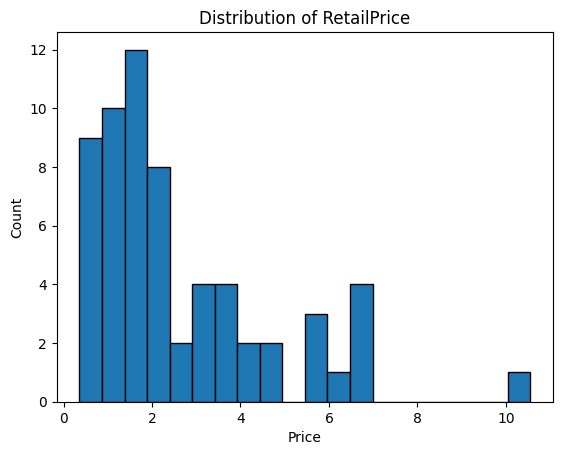

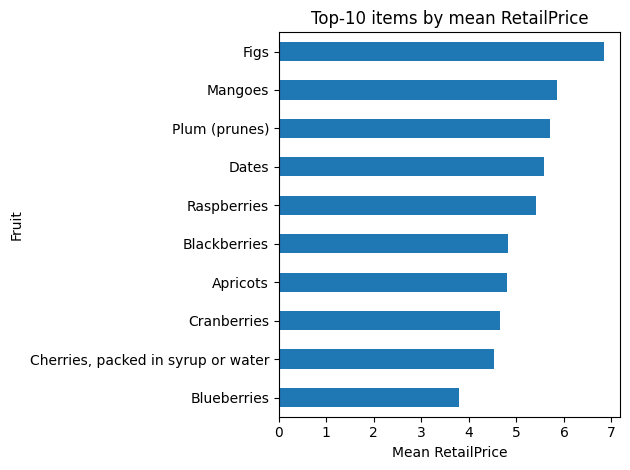

\nUnique RetailPriceUnit values: ['per pound', 'per pint']
Unique CupEquivalentUnit values: ['pounds', 'fluid ounces']


In [5]:
# Step 5 — quick EDA (Exploratory Data Analysis — it’s the initial stage where we “get to know” the data before building any model)
PRICE_COL = "RetailPrice"
ITEM_COL  = "Fruit"
FORM_COL  = "Form"

print("Rows, Cols:", df.shape)
print("\\nMissing ratio per column:")
print(df.isna().mean().sort_values(ascending=False))

# sanity checks
assert PRICE_COL in df.columns, f"{PRICE_COL} not found"
assert ITEM_COL  in df.columns, f"{ITEM_COL} not found"
assert FORM_COL  in df.columns, f"{FORM_COL} not found"

# duplicates check
dups = df.duplicated(subset=[ITEM_COL, FORM_COL, PRICE_COL]).sum()
print("\\nPotential duplicate rows (by item+form+price):", dups)

# histogram
plt.figure()
df[PRICE_COL].plot(kind="hist", bins=20, edgecolor="black")
plt.title(f"Distribution of {PRICE_COL}")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# top-10 by mean price per item (if ITEM_COL exists)
top10 = (
    df.groupby(ITEM_COL)[PRICE_COL]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure()
top10.sort_values().plot(kind="barh")
plt.title("Top-10 items by mean RetailPrice")
plt.xlabel("Mean RetailPrice")
plt.ylabel(ITEM_COL)
plt.tight_layout()
plt.show()

print("\\nUnique RetailPriceUnit values:", df["RetailPriceUnit"].unique().tolist())
print("Unique CupEquivalentUnit values:", df["CupEquivalentUnit"].unique().tolist())


In [6]:
# Step 6 — target labels + feature set
df = df.copy()
df["PriceCategory"] = pd.qcut(df[PRICE_COL], q=3, labels=["low", "mid", "high"])
print(df["PriceCategory"].value_counts())

feature_cats = ["Fruit", "Form", "RetailPriceUnit", "CupEquivalentUnit"]
target_col = "PriceCategory"

X = df[feature_cats].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("\\nTrain/Test shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


PriceCategory
low     21
high    21
mid     20
Name: count, dtype: int64
\nTrain/Test shapes:
X_train: (49, 4) X_test: (13, 4)
y_train: (49,) y_test: (13,)


In [7]:
# Step 7 — train baseline models (LogReg & RandomForest)

# OneHotEncoder compatibility for different scikit-learn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[("cat", ohe, feature_cats)],
    remainder="drop"
)

logreg_clf = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=500, random_state=RANDOM_STATE))
])

rf_clf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE
    ))
])

models = {"LogisticRegression": logreg_clf, "RandomForest": rf_clf}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    results.append((name, acc, f1m))
    print(f"\\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-macro: {f1m:.4f}")
    print(classification_report(y_test, y_pred, digits=4))

print("\\nSummary:")
for r in results:
    print(f"{r[0]:20s}  Accuracy={r[1]:.3f}  F1-macro={r[2]:.3f}")


\n=== LogisticRegression ===
Accuracy: 0.5385
F1-macro: 0.5278
              precision    recall  f1-score   support

        high     1.0000    0.6000    0.7500         5
         low     0.3750    0.7500    0.5000         4
         mid     0.5000    0.2500    0.3333         4

    accuracy                         0.5385        13
   macro avg     0.6250    0.5333    0.5278        13
weighted avg     0.6538    0.5385    0.5449        13

\n=== RandomForest ===
Accuracy: 0.5385
F1-macro: 0.5278
              precision    recall  f1-score   support

        high     1.0000    0.6000    0.7500         5
         low     0.3750    0.7500    0.5000         4
         mid     0.5000    0.2500    0.3333         4

    accuracy                         0.5385        13
   macro avg     0.6250    0.5333    0.5278        13
weighted avg     0.6538    0.5385    0.5449        13

\nSummary:
LogisticRegression    Accuracy=0.538  F1-macro=0.528
RandomForest          Accuracy=0.538  F1-macro=0.528


Best model: LogisticRegression


<Figure size 640x480 with 0 Axes>

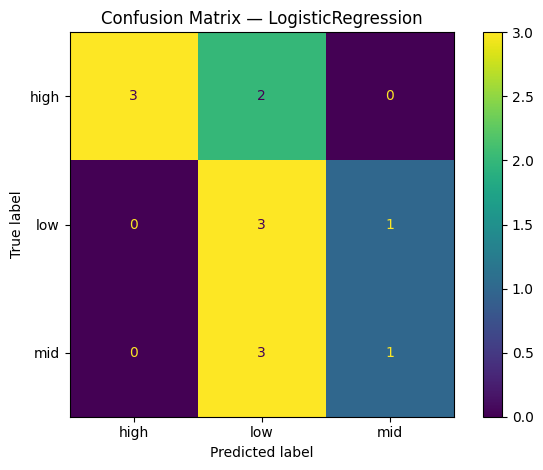

Saved: /content/confusion_matrix.png
Feature importances displayed only for RandomForest.


<Figure size 640x480 with 0 Axes>

In [8]:
# Step 8 — confusion matrix (and feature importances if RF best)
best_model_name = sorted(results, key=lambda x: x[2], reverse=True)[0][0]
best_model = models[best_model_name]
print("Best model:", best_model_name)

y_pred_best = best_model.predict(X_test)
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

# Save confusion matrix if needed
out_png = WORKDIR / "confusion_matrix.png"
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig(str(out_png), bbox_inches="tight")
plt.close()
print("Saved:", out_png)

# Feature importances (only for RF)
if best_model_name == "RandomForest":
    ohe_fitted = best_model.named_steps["prep"].named_transformers_["cat"]
    feature_names = list(ohe_fitted.get_feature_names_out(feature_cats))
    rf = best_model.named_steps["clf"]
    importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(importances.head(20))
else:
    print("Feature importances displayed only for RandomForest.")


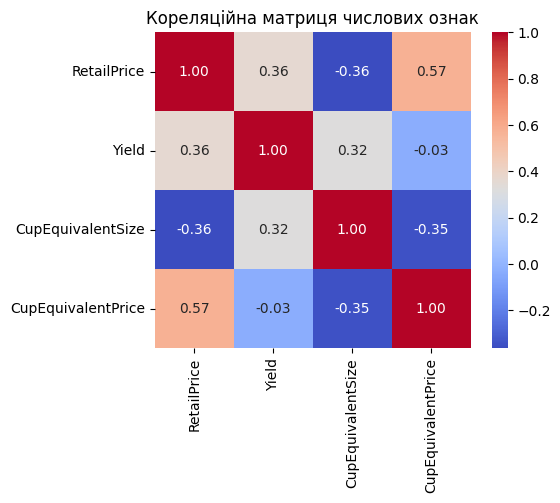

In [9]:
!pip -q install seaborn
import seaborn as sns

num_cols = df.select_dtypes(include=["number"])
corr = num_cols.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Кореляційна матриця числових ознак")
plt.tight_layout()
plt.show()


DecisionTree  Accuracy=0.5385  F1-macro=0.5278
              precision    recall  f1-score   support

        high     1.0000    0.6000    0.7500         5
         low     0.3750    0.7500    0.5000         4
         mid     0.5000    0.2500    0.3333         4

    accuracy                         0.5385        13
   macro avg     0.6250    0.5333    0.5278        13
weighted avg     0.6538    0.5385    0.5449        13



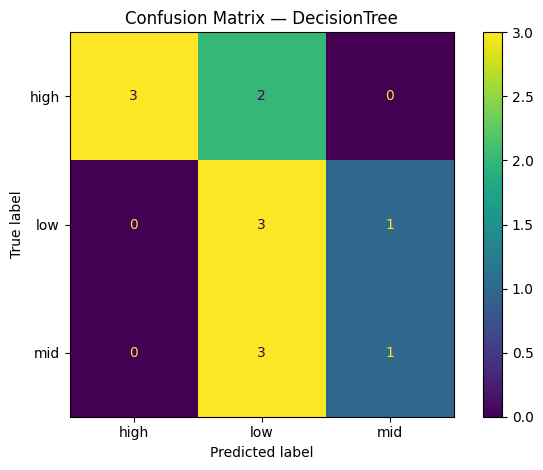

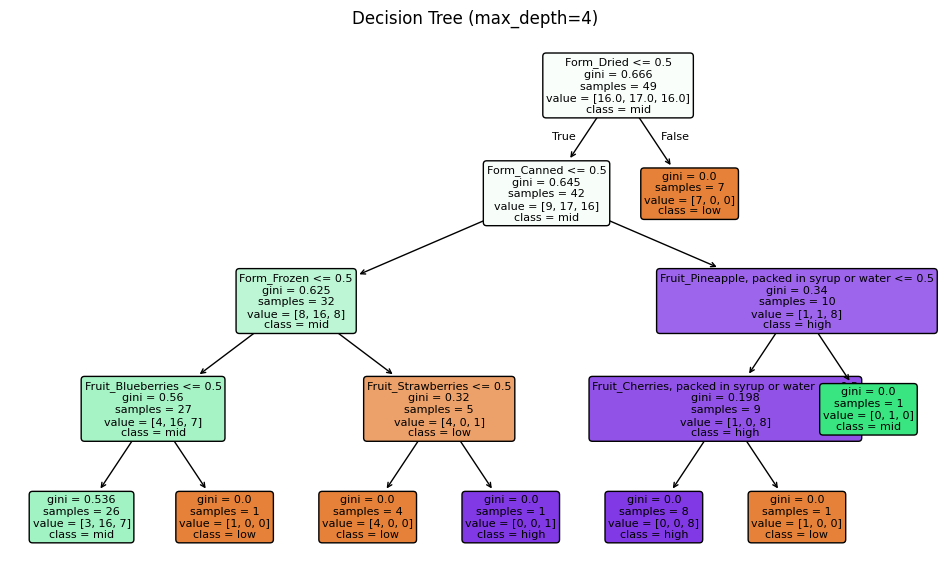

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_clf = Pipeline([
    ("prep", preprocess),  # той самий ColumnTransformer з OHE
    ("clf", DecisionTreeClassifier(
        max_depth=4, random_state=RANDOM_STATE
    ))
])

dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average="macro")
print(f"DecisionTree  Accuracy={acc_dt:.4f}  F1-macro={f1_dt:.4f}")
print(classification_report(y_test, y_pred_dt, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Confusion Matrix — DecisionTree")
plt.tight_layout(); plt.show()

# (опційно) Візуалізація дерева (після препроцесингу)
# Витягнемо вже навчене “чисте” дерево
dt = dt_clf.named_steps["clf"]
ohe_fitted = dt_clf.named_steps["prep"].named_transformers_["cat"]
feat_names = list(ohe_fitted.get_feature_names_out(feature_cats))

plt.figure(figsize=(12,7))
plot_tree(dt, feature_names=feat_names, class_names=["low","mid","high"],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (max_depth=4)")
plt.show()


Задача класифікації: на основі ознак
`Fruit`, `Form`, `RetailPriceUnit`, `CupEquivalentUnit`
передбачити категорію ціни (`low`, `mid`, `high`), утворену з терцилів значення RetailPrice.

Аналіз даних (EDA)

* Кількість рядків — 62, пропусків немає.
* Поля описують вид фрукту, форму (свіжий, сік, консервований тощо), одиниці вимірювання та ціни.
* Розподіл цін має 2 типи одиниць: «per pound» і «per pint».
* Дані чисті та придатні до моделювання.

Підготовка даних

* Створено мітку PriceCategory (три класи за терцилями).
* Використано One-Hot Encoding для категоріальних ознак.
* Вибірка розділена у співвідношенні 80/20 (49 тренувальних, 13 тестових рядків)

Моделі:

1. LogisticRegression — базова лінійна модель.
2. RandomForestClassifier — ансамблевий метод дерев.
3. DecisionTreeClassifier - дерево рішень для класифікації.

Метрики оцінювання: Accuracy та F1-macro (балансує класи).

| Model               | Accuracy | F1-macro |
| :------------------ | :------: | :------: |
| Logistic Regression |   0.538  |   0.528  |
| Random Forest       |   0.538  |   0.528  |
| DecisionTreeClassifier       |   0.538  |   0.528  |


Результати та аналіз

* Обидві моделі дали ідентичну якість (≈ 54 % точності).
* Приклад матриці плутанини показує найбільше переплутування між класами `mid` та `low`.
* Для таких невеликих даних результат очікуваний: бракує варіативності для глибоких залежностей.

Висновки

* Навчено та порівняно два базові класифікатори.
* Додатково побудовано DecisionTreeClassifier, який показав ідентичні результати (Accuracy ≈ 0.54, F1 ≈ 0.53), що підтверджує стабільність отриманих висновків
* Дані чисті, балансовані, але малий обсяг (62 рядки) обмежує якість.
* Обидва методи демонструють однакову продуктивність на тестовій вибірці.
* Для покращення можна додати більше ознак (наприклад, сезонність, країну походження чи вагу упаковки)

Відповіді на контрольні запитання до лабораторної роботи №1

1. Основні поняття та означення

Штучний інтелект (ШІ) — галузь інформатики, що досліджує методи й моделі моделювання інтелектуальної поведінки людини в апаратно-програмних системах.
Основні поняття: дані, інформація, знання, модель, база знань, навчання, інтелектуальна система

2. Поняття штучного інтелекту

За визначенням з лекції №1:
ШІ — це наукова дисципліна, мета якої — розробка математичних описів функцій людського інтелекту та їх реалізація засобами обчислювальної техніки.
Системи ШІ можуть думати подібно до людини, діяти раціонально, діяти як людина або думати раціонально (чотири класичні підходи згідно з Russell & Norvig, AIMA)

3. Структуровані та неструктуровані дані

* Структуровані дані — мають чітку таблицю чи схему (рядки, стовпці, типи). Приклади: CSV, SQL-таблиці.
* Неструктуровані дані — текст, зображення, відео, звукові записи, документи без фіксованої схеми.

4. Підготовка та дослідження даних

Процес включає:

* Збір даних.
* Первинний аналіз (EDA).
* Чищення (видалення пропусків, дублікатів).
* Кодування ознак.
* Масштабування й нормалізація (за потреби).
* Розбиття на навчальний і тестовий набори.

5. Проблеми при роботі з великими даними

* Недостатній розмір або неповнота даних.
* Непредставницькі вибірки.
* Несуттєві або шумові ознаки.
* Погана якість даних, перенавчання.

6. Мови програмування для обробки даних

Найпоширеніші:

* Python (NumPy, Pandas, SciPy, Scikit-learn, TensorFlow).
* R — статистичний аналіз.
* SQL — робота зі структурованими даними.
* Java, Scala — Big Data-платформи (Hadoop, Spark)

7. Технології роботи з DataSet

Використовуються:

* Платформи відкритих даних: Kaggle, UCI ML Repository, data.world.
* Інструменти: Pandas (читання CSV, Excel, SQL), Scikit-learn (load_* функції), TensorFlow Datasets

8. Процес моделювання: вибір моделі, тренування та перевірка на адекватність

* Вибір моделі (лінійна, дерево, нейромережа).
* Тренування — підбір параметрів на навчальній вибірці.
* Перевірка адекватності — оцінка метрик (Accuracy, F1, RMSE тощо) на тестових даних.
* Валідація — крос-перевірка (cross-validation)

9. Різні бібліотеки при роботі з даними

* NumPy — робота з масивами.
* Pandas — таблиці, групування, фільтрація.
* Matplotlib / Seaborn — візуалізація.
* SciPy — наукові обчислення.
* Scikit-learn — моделі машинного навчання.
* TensorFlow / PyTorch — глибоке навчання.

10. Кодування ознак

Процес перетворення категоріальних змінних у числові:

* One-Hot Encoding — для невеликих множин значень.
* Label Encoding — заміна категорій на цілі числа.
* Target / Frequency Encoding — для великої кардинальності.

11. Перехід від категоріальних ознак

Категоріальні ознаки не можуть напряму оброблятися більшістю моделей → їх перетворюють у числовий вигляд (через кодування або вбудовані словники).
Напр., `Form = Fresh, Juice, Canned` → три двійкові колонки (0/1).

12. Контрольоване та неконтрольоване навчання моделі

* Контрольоване навчання (supervised) — є відомі цільові значення (класи або числа).
* Неконтрольоване (unsupervised) — модель шукає структуру самостійно (кластеризація, зниження розмірності).

13. Загальні поняття машинного навчання

Машинне навчання — підгалузь ШІ, де система вчиться на основі даних, а не за наперед заданими правилами.
Типи: з учителем, без учителя, з підкріпленням.

14. Робота з масивами даних

* Використовується NumPy (array, reshape, arange, zeros, ones).
* Масиви дозволяють векторизовані операції, що швидше за цикли Python.

15. Бібліотеки Python для роботи з даними

Основні:
| Бібліотека                | Призначення              |
| ------------------------- | ------------------------ |
| **NumPy**                 | Масиви, вектори, матриці |
| **Pandas**                | Таблиці, DataFrame       |
| **Matplotlib**            | Базова візуалізація      |
| **Seaborn**               | Статистичні графіки      |
| **SciPy**                 | Обчислення, статистика   |
| **Scikit-learn**          | ML-алгоритми             |

16. Бібліотека Scikit-learn та вбудовані в неї масиви даних

Scikit-learn — універсальний фреймворк для машинного навчання: моделі, метрики, препроцесинг, розбиття даних.
Містить вбудовані набори даних: load_iris(), load_wine(), load_breast_cancer() тощо.

17. Методи роботи з наборами даних: завантаження, візуалізація та розбиття

* Завантаження: pd.read_csv(), sklearn.datasets.load_*().
* Візуалізація: plt.hist(), sns.boxplot(), sns.pairplot().
* Розбиття: train_test_split() (Scikit-learn).

18. Бібліотека Pandas та її можливості

* Структури Series і DataFrame.
* Методи: head(), info(), describe(), groupby(), merge(), pivot_table().
* Робота з пропущеними значеннями (fillna(), dropna()).

19. Бібліотека Seaborn та її можливості

* Побудова статистичних графіків (розподіли, кореляції, heatmaps).
* Працює поверх Matplotlib і інтегрується з Pandas.
* Основні функції: sns.histplot(), sns.boxplot(), sns.pairplot(), sns.heatmap().